In [1]:
from xaikd import datasets, attributors, models,bases
from xaikd.utils import metrics
from matplotlib import pyplot as plt 

import numpy as np 

import torch

from torch.nn import functional as F

from tqdm import tqdm 

from pathlib import Path

In [2]:
DEVICE="cuda"
LAYER = "layer3"

MODEL_NAME = "cifar100-resnet18-p1"

In [3]:
dataset = datasets.construct("cifar100")

In [4]:
model = models.get_model(MODEL_NAME).to(DEVICE)

In [5]:
logit_mod = attributors.OneClassEvidence(dataset)

arr_act, arr_ctx = attributors.extract_activation_context(
    model, 
    layer=LAYER,
    dataset=dataset, 
    logit_modifier=logit_mod,
    data_loader=dataset.loader(train_split=True),
    device=DEVICE
)

100%|███████████████████████████████████████████████| 782/782 [02:55<00:00,  4.45it/s]


layer3: output-dims=torch.Size([256, 8, 8])


In [6]:
act_mean = np.mean(arr_act, axis=0)

In [7]:
SAVE_PATH = Path("./tmp")


In [8]:
# np.save(SAVE_PATH / "act_mean.npy", act_mean)
act_mean = np.load(SAVE_PATH / "act_mean.npy")

In [9]:
basis_pca = bases.get_basis("pca--centered")
# basis_pca.fit(arr_act, None, mean=act_mean)
# basis_pca.save(SAVE_PATH)
basis_pca.load(SAVE_PATH)

In [10]:
basis_prca = bases.get_basis("prca-abs--centered")
# basis_prca.fit(arr_act, arr_ctx, mean=act_mean, device=DEVICE)
# basis_prca.save(SAVE_PATH)
basis_prca.load(SAVE_PATH)

In [11]:
val_dl = dataset.loader(train_split=False)

((256,), torch.Size([256, 256]))

In [14]:
# # basis_identity = bases.get_basis("identity--centered")
# # # basis_identity.fit(arr_act, arr_ctx, mean=act_mean, device=DEVICE)
# # # basis_identity.save(SAVE_PATH)
# # # basis_identity.load(SAVE_PATH)
# def construct_fh_hook_projection(basis):

    
#     decoder = basis
#     A = torch.from_numpy(U @ U.T).float().unsqueeze(2).unsqueeze(3)
#     mean = torch.from_numpy(mean).reshape((1, -1, 1, 1))
    
#     def fh(mod, input, output):
#         assert isinstance(output, torch.Tensor)

#         return F.conv2d(output - mean, A) + mean

#     return fh

# act_mean.shape, basis_prca.artifact["eigvecs"].shape

from torch.nn import functional as  F
def ano():
    
    k = 256
    
    torch.manual_seed(1)
    x = torch.randn(8, 256, 1, 1)
    
    adapter = basis_pca.construct_adapter(k, mode=bases.AdapterMode.ENCODER, device="cpu")

    
    std = basis_pca.artifact["std"].reshape((1, -1, 1, 1)) 

    
    U = basis_pca.artifact["eigvecs"]
    mean = torch.from_numpy(act_mean).reshape((1, -1, 1, 1))

    
    Uenc = U.T.unsqueeze(2).unsqueeze(3)
    
    Udec = U.unsqueeze(2).unsqueeze(3)
    
    np.testing.assert_allclose(
        adapter.mat_encoder,
        Uenc
    )
    
    np.testing.assert_allclose(
        adapter.mat_decoder,
        Udec
    )
    
    np.testing.assert_allclose(
        adapter.std,
        std
    )
    
    scaling = std + bases.EPS
    
    np.testing.assert_allclose(
        adapter.mean,
        mean
    )
    
    
    def encode(x):
        return F.conv2d(x - mean, Uenc) / scaling
    def decode(x):
        return F.conv2d(x * scaling, Udec) + mean
    
    
    
    
    
#     decode = basis_pca.construct_adapter(k, mode=bases.AdapterMode.DECODER, device="cpu")
    
    np.testing.assert_allclose(x, decode(encode(x)), atol=1e-5)
    
    np.testing.assert_allclose(
         adapter.encoder(x), 
         encode(x),
         atol=1e-5
     )

    
    np.testing.assert_allclose(
         adapter.decoder(adapter.encoder(x)),
         decode(adapter.encoder(x)),
         atol=1e-5
     )
    np.testing.assert_allclose(x, adapter.decoder(adapter.encoder(x)), atol=1e-5)

    print("passed!")
ano()

passed!


In [16]:
metrics.accuracy(model, val_dl, num_classes=100, device=DEVICE)

0.6840000152587891

In [22]:
def compute_acc(model, basis, k):
    
    module = getattr(model, LAYER)[-1]
#     U = eigvecs[:, :k]
    
    try:
        hook = module.register_forward_hook(
            basis.construct_fh_rank_k_projection(k=k, device=DEVICE)
        )

        acc = metrics.accuracy(model, val_dl, num_classes=100, device=DEVICE)
        print(f"acc@{k}={acc:.4f}")
    finally:
        hook.remove()
        
compute_acc(model, basis_pca, k=50)

acc@50=0.5969


In [23]:
compute_acc(model, basis_prca, k=50)

acc@50=0.6103


In [32]:
class ProjectionLayer(torch.nn.Module):
    def __init__(self, basis, k):
        
        super().__init__()
        
        self.encoder = basis.construct_adapter(k, mode=bases.AdapterMode.ENCODER, device=DEVICE)
        self.decoder = basis.construct_adapter(k, mode=bases.AdapterMode.DECODER, device=DEVICE)

    def forward(self, x):
        return self.decoder(self.encoder(x))

In [39]:
def get_modified_model(basis, k):

    modified_model = models.get_model(MODEL_NAME)
    setattr(modified_model, LAYER, 
        torch.nn.Sequential(
            getattr(modified_model, LAYER),
            ProjectionLayer(basis, k)
        )
    )

    return modified_model.to(DEVICE)


modified_pca_model = get_modified_model(basis_pca, 50)
modified_pca_model(torch.randn(10, 3, 32, 32).to(DEVICE))

tensor([[ 1.8840e-01, -7.4723e-01,  2.0584e-02, -1.7510e+00,  6.7740e-01,
          2.6253e+00, -1.1282e+00, -4.0980e-01,  1.4029e+00, -2.1571e-01,
          1.7400e-01, -1.1224e+00,  2.8559e+00,  5.7339e-01,  2.9027e-01,
         -1.4762e+00,  2.0165e+00, -2.0501e-01,  1.5128e+00, -5.5161e-01,
         -8.3863e-02, -3.6450e-01,  2.8734e-01,  3.6249e-02, -1.0954e+00,
          1.9409e+00, -9.7457e-01, -9.3255e-01, -1.1300e+00, -1.8646e+00,
         -1.5328e+00, -6.9681e-01, -1.3996e+00,  7.5640e+00, -1.4140e+00,
          2.8293e-01, -8.4993e-01, -6.1915e-01, -1.7505e+00,  1.6592e+00,
         -1.4828e+00,  6.7458e-02, -5.4949e-01, -1.3828e+00, -2.3493e+00,
          1.0333e+00, -2.3667e-01,  2.9031e-01, -7.7181e-01, -8.4500e-03,
         -8.2781e-01, -1.2261e+00, -1.1088e+00,  8.9830e-01, -2.1166e-01,
         -1.3511e+00,  4.6897e-01,  3.6086e+00, -9.2106e-01,  1.9038e+00,
          1.5494e+00,  3.2498e-01,  1.2901e-01, -3.7941e-01, -1.3676e+00,
         -1.2016e+00, -1.6441e+00, -1.

In [41]:
metrics.accuracy(modified_pca_model, val_dl, num_classes=100, device=DEVICE)

0.5968999862670898

In [42]:
modified_prca_model = get_modified_model(basis_prca, 50)

metrics.accuracy(modified_prca_model, val_dl, num_classes=100, device=DEVICE)

0.6103000044822693

In [44]:
def compute_grad_norm(model, threshold=1000):
    
    count = 0
    
    arr_norms = []
    for x, y in tqdm(val_dl):
        
        x.requires_grad_(True)
        
        model(x.to(DEVICE))[:, y].sum().backward()
                
        grad = x.grad.flatten(start_dim=1)
        arr_norms.append(
            torch.linalg.norm(grad, dim=1).detach().cpu().numpy()
        )
        
        count += grad.shape[0]
        
#         if count > 2000:
#             break
    
    return np.concatenate(arr_norms)
    

normal_model_grad = compute_grad_norm(model)

normal_model_grad.shape

100%|███████████████████████████████████████████████| 157/157 [00:07<00:00, 21.18it/s]


(10000,)

In [45]:
modified_pca_model_grad = compute_grad_norm(modified_pca_model)

100%|███████████████████████████████████████████████| 157/157 [00:07<00:00, 21.77it/s]


In [46]:
modified_prca_model_grad = compute_grad_norm(modified_prca_model)

100%|███████████████████████████████████████████████| 157/157 [00:07<00:00, 21.91it/s]


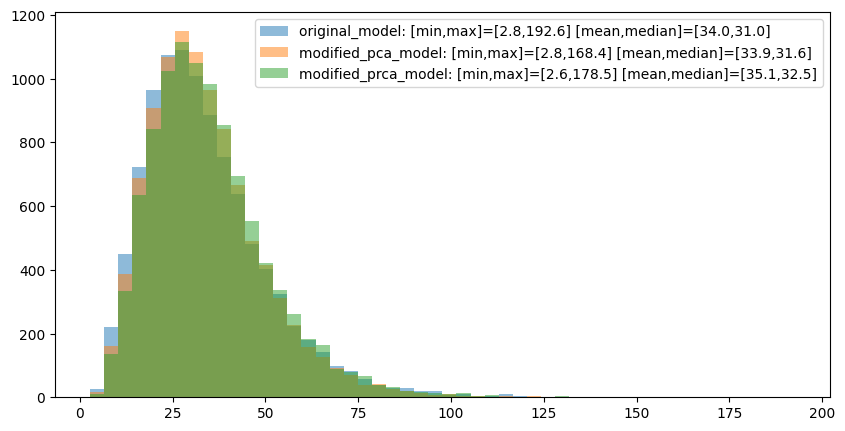

In [47]:
def viz():
    
    
    plt.figure(figsize=(10, 5))
    bins = None
    for label, grad in [
        ("original_model", normal_model_grad),
        ("modified_pca_model", modified_pca_model_grad),
        ("modified_prca_model", modified_prca_model_grad)
    ]:
        
        label = f"{label}: [min,max]=[{np.min(grad):.1f},{np.max(grad):.1f}] [mean,median]=[{np.mean(grad):.1f},{np.median(grad):.1f}]"
        _, bins, _ = plt.hist(
            grad, label=label, bins=bins if bins is not None else 50,
            alpha=0.5
        )
    plt.legend()
viz()


In [63]:
normal_model_grad.shape

(4, 64)